In [1]:
import sqlite3 as sq3
import pandas as pd
from IPython.display import display

con = sq3.connect("C:/Users/cassi/Documents/JHU/Biomedical_Data_Science/opioid.db")
sql = con.cursor()

county_annual = pd.read_sql_query("SELECT * from annual", con)
county_pop = pd.read_sql_query("SELECT * from population", con)
land = pd.read_sql_query("SELECT * from land", con)

con.close()

display(county_annual.head())
display(county_pop.head())
display(land.head())

missing_fips = county_annual[county_annual["countyfips"] == "NA"]
print("rows with missing countyfips:", len(missing_fips))
display(missing_fips.head(10))

missing_not_pr = county_annual[(county_annual["countyfips"] == "NA") & (county_annual["BUYER_STATE"] != "PR")]
print("missing countyfips, outside PR:", len(missing_not_pr))
missing_not_pr["BUYER_STATE"].value_counts()

mask = (county_annual["BUYER_STATE"] == "AR") & (county_annual["BUYER_COUNTY"] == "MONTGOMERY")
print("before fix:", county_annual.loc[mask, "countyfips"].unique())

county_annual.loc[mask, "countyfips"] = "05097"

print("after fix:", county_annual.loc[mask, "countyfips"].unique())

print("before:", (county_annual["BUYER_COUNTY"] == "NA").sum())

county_annual = county_annual[county_annual["BUYER_COUNTY"] != "NA"].reset_index(drop=True)

print("after:", (county_annual["BUYER_COUNTY"] == "NA").sum())

land_area = land[["Areaname", "STCOU", "LND110210D"]].copy()
land_area = land_area.rename(columns={"STCOU": "countyfips"})

county_info = county_pop.merge(land_area, on="countyfips", how="left")

print("land:", len(land))                
print("land_area:", len(land_area))        
print("county_info:", len(county_info))     
print("county_pop:", len(county_pop))       


,?,BUYER_COUNTY,BUYER_STATE,year,count,DOSAGE_UNIT,countyfips
0,1,ABBEVILLE,SC,2006,877,363620.0,45001
1,2,ABBEVILLE,SC,2007,908,402940.0,45001
2,3,ABBEVILLE,SC,2008,871,424590.0,45001
3,4,ABBEVILLE,SC,2009,930,467230.0,45001
4,5,ABBEVILLE,SC,2010,1197,539280.0,45001


,?,BUYER_COUNTY,BUYER_STATE,countyfips,STATE,COUNTY,county_name,NAME,variable,year,population
0,1,AUTAUGA,AL,1001,1,1,Autauga,"Autauga County, Alabama",B01003_001,2006,51328
1,2,BALDWIN,AL,1003,1,3,Baldwin,"Baldwin County, Alabama",B01003_001,2006,168121
2,3,BARBOUR,AL,1005,1,5,Barbour,"Barbour County, Alabama",B01003_001,2006,27861
3,4,BIBB,AL,1007,1,7,Bibb,"Bibb County, Alabama",B01003_001,2006,22099
4,5,BLOUNT,AL,1009,1,9,Blount,"Blount County, Alabama",B01003_001,2006,55485


,?,Areaname,STCOU,LND010190F,LND010190D,LND010190N1,LND010190N2,LND010200F,LND010200D,LND010200N1,...,LND110210N1,LND110210N2,LND210190F,LND210190D,LND210190N1,LND210190N2,LND210200F,LND210200D,LND210200N1,LND210200N2
0,1,UNITED STATES,0,0,3787425.08,0,0,0,3794083.06,0,...,0,0,0,251083.35,0,0,0,256644.62,0,0
1,2,ALABAMA,1000,0,52422.94,0,0,0,52419.02,0,...,0,0,0,1672.71,0,0,0,1675.01,0,0
2,3,"Autauga, AL",1001,0,604.49,0,0,0,604.45,0,...,0,0,0,8.48,0,0,0,8.48,0,0
3,4,"Baldwin, AL",1003,0,2027.08,0,0,0,2026.93,0,...,0,0,0,430.55,0,0,0,430.58,0,0
4,5,"Barbour, AL",1005,0,904.59,0,0,0,904.52,0,...,0,0,0,19.59,0,0,0,19.61,0,0


rows with missing countyfips: 760


,?,BUYER_COUNTY,BUYER_STATE,year,count,DOSAGE_UNIT,countyfips
187,188,ADJUNTAS,PR,2006,147,102800.0,NA
188,189,ADJUNTAS,PR,2007,153,104800.0,NA
189,190,ADJUNTAS,PR,2008,153,45400.0,NA
190,191,ADJUNTAS,PR,2009,184,54200.0,NA
191,192,ADJUNTAS,PR,2010,190,56200.0,NA
192,193,ADJUNTAS,PR,2011,186,65530.0,NA
193,194,ADJUNTAS,PR,2012,138,57330.0,NA
194,195,ADJUNTAS,PR,2013,138,65820.0,NA
195,196,ADJUNTAS,PR,2014,90,59490.0,NA
196,197,AGUADA,PR,2006,160,49200.0,NA


missing countyfips, outside PR: 74
before fix: ['NA']
after fix: ['05097']
before: 17
after: 0
land: 3198
land_area: 3198
county_info: 28265
county_pop: 28265


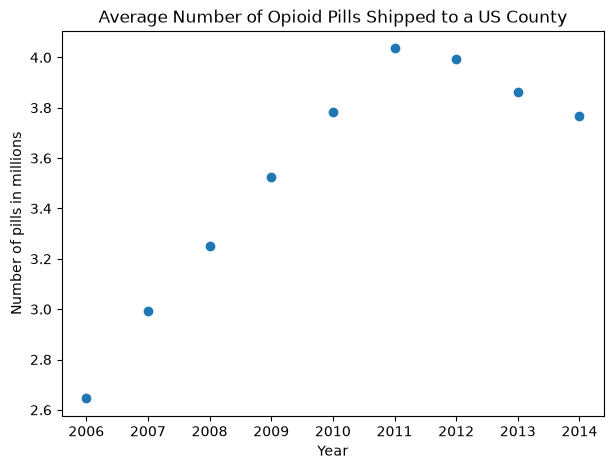

In [2]:
import sqlite3 as sq3
import pandas as pd
import matplotlib.pyplot as plt

con = sq3.connect("C:/Users/cassi/Documents/JHU/Biomedical_Data_Science/opioid.db")
annual = pd.read_sql_query("SELECT * from annual", con)
con.close()

annual["DOSAGE_UNIT"] = annual["DOSAGE_UNIT"].astype(float)
annual["Pills_in_millions"] = annual["DOSAGE_UNIT"] / 1_000_000

yearly_avg = annual.groupby("year", as_index=False)["Pills_in_millions"].mean()

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(yearly_avg["year"], yearly_avg["Pills_in_millions"])
ax.set_title("Average Number of Opioid Pills Shipped to a US County")
ax.set_xlabel("Year")
ax.set_ylabel("Number of pills in millions")
plt.show()

In [3]:
import os
import rpy2.robjects as robjects
from rpy2.robjects import pandas2ri
from rpy2.robjects.conversion import localconverter

CSV_DIR = "C:/Users/cassi/Documents/JHU/Biomedical_Data_Science"


print(os.path.exists(os.path.join(CSV_DIR, "wrangle.R")))
print(os.listdir(CSV_DIR))

robjects.r(f'setwd("{CSV_DIR}")') 
robjects.r.source("wrangle.R")    

with localconverter(robjects.default_converter + pandas2ri.converter):
   county_info = robjects.conversion.rpy2py(robjects.r["county_info"])

print(type(county_info))   
print(county_info.shape)  
county_info.head()

Error importing in API mode: ImportError('On Windows, cffi mode "ANY" is only "ABI".')
Trying to import in ABI mode.


True
['Assignment1', 'county_annual.csv', 'county_pop_arcos.csv', 'ds4bio_assignments', 'gitrepository', 'hw4R.ipynb', 'land_area.csv', 'opioid.db', 'sqldiff.exe', 'sqlite3.exe', 'sqlite3_analyzer.exe', 'sqlite3_rsync.exe', 'wrangle.R']
population: 28265 rows, 11 cols
annual: 27758 rows, 7 cols
land: 3198 rows, 35 cols

missing countyfips in annual: 760 
missing countyfips, outside PR: 74 

AE AR CA CT FL GA GU IA IN MA MP NV OH PW VI 
 1  9  1  3  2  1  9  1  1  1  9  3  1  5 27 

Montgomery AR countyfips before fix: NA 
Montgomery AR countyfips after fix: 05097 

rows with BUYER_COUNTY NA (before): 17 
rows with BUYER_COUNTY NA (after): 0 

land: 3198 
land_area: 3198 
county_info: 28265 
population: 28265 
<class 'pandas.DataFrame'>
(28265, 13)


,countyfips,X,BUYER_COUNTY,BUYER_STATE,STATE,COUNTY,county_name,NAME,variable,year,population,Areaname,LND110210D
1,01001,12567,AUTAUGA,AL,1,1,Autauga,"Autauga County, Alabama",B01003_001,2010,53155,"Autauga, AL",594.44
2,01001,6285,AUTAUGA,AL,1,1,Autauga,"Autauga County, Alabama",B01003_001,2008,53277,"Autauga, AL",594.44
3,01001,3143,AUTAUGA,AL,1,1,Autauga,"Autauga County, Alabama",B01003_001,2007,52405,"Autauga, AL",594.44
4,01001,9427,AUTAUGA,AL,1,1,Autauga,"Autauga County, Alabama",B01003_001,2009,49584,"Autauga, AL",594.44
5,01001,1,AUTAUGA,AL,1,1,Autauga,"Autauga County, Alabama",B01003_001,2006,51328,"Autauga, AL",594.44
